In [1]:
# Ver qué archivos hay en sample_data
import os
print(os.listdir('/content/sample_data/'))

['anscombe.json', 'README.md', 'mnist_train_small.csv', 'california_housing_test.csv', 'mnist_test.csv', 'california_housing_train.csv']


In [2]:
['archivo1.csv', 'archivo2.csv', 'README.md', ...]

['archivo1.csv', 'archivo2.csv', 'README.md', Ellipsis]

In [3]:
import os
print(os.listdir('/content/sample_data/'))

['anscombe.json', 'README.md', 'mnist_train_small.csv', 'california_housing_test.csv', 'mnist_test.csv', 'california_housing_train.csv']


In [4]:
import pandas as pd

# Cargar datos de entrenamiento
train = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Ver las primeras 5 filas
print(train.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


In [5]:
# Matriz de correlación
correlation_matrix = train.corr()
print("Matriz de correlación:")
print(correlation_matrix)

Matriz de correlación:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.925208           -0.114250     0.047010   
latitude            -0.925208  1.000000            0.016454    -0.038773   
housing_median_age  -0.114250  0.016454            1.000000    -0.360984   
total_rooms          0.047010 -0.038773           -0.360984     1.000000   
total_bedrooms       0.071802 -0.069373           -0.320434     0.928403   
population           0.101674 -0.111261           -0.295890     0.860170   
households           0.059628 -0.074902           -0.302754     0.919018   
median_income       -0.015485 -0.080303           -0.115932     0.195383   
median_house_value  -0.044982 -0.144917            0.106758     0.130991   

                    total_bedrooms  population  households  median_income  \
longitude                 0.071802    0.101674    0.059628      -0.015485   
latitude                 -0.069373   -0.111261   -0.074902    

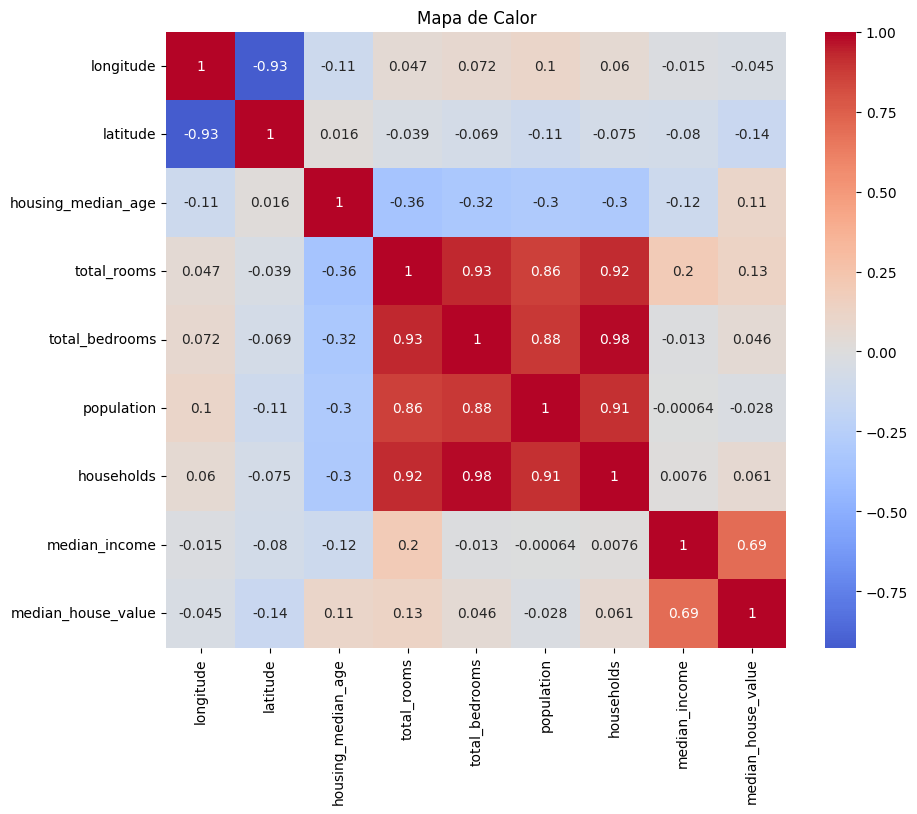

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de Calor')
plt.show()

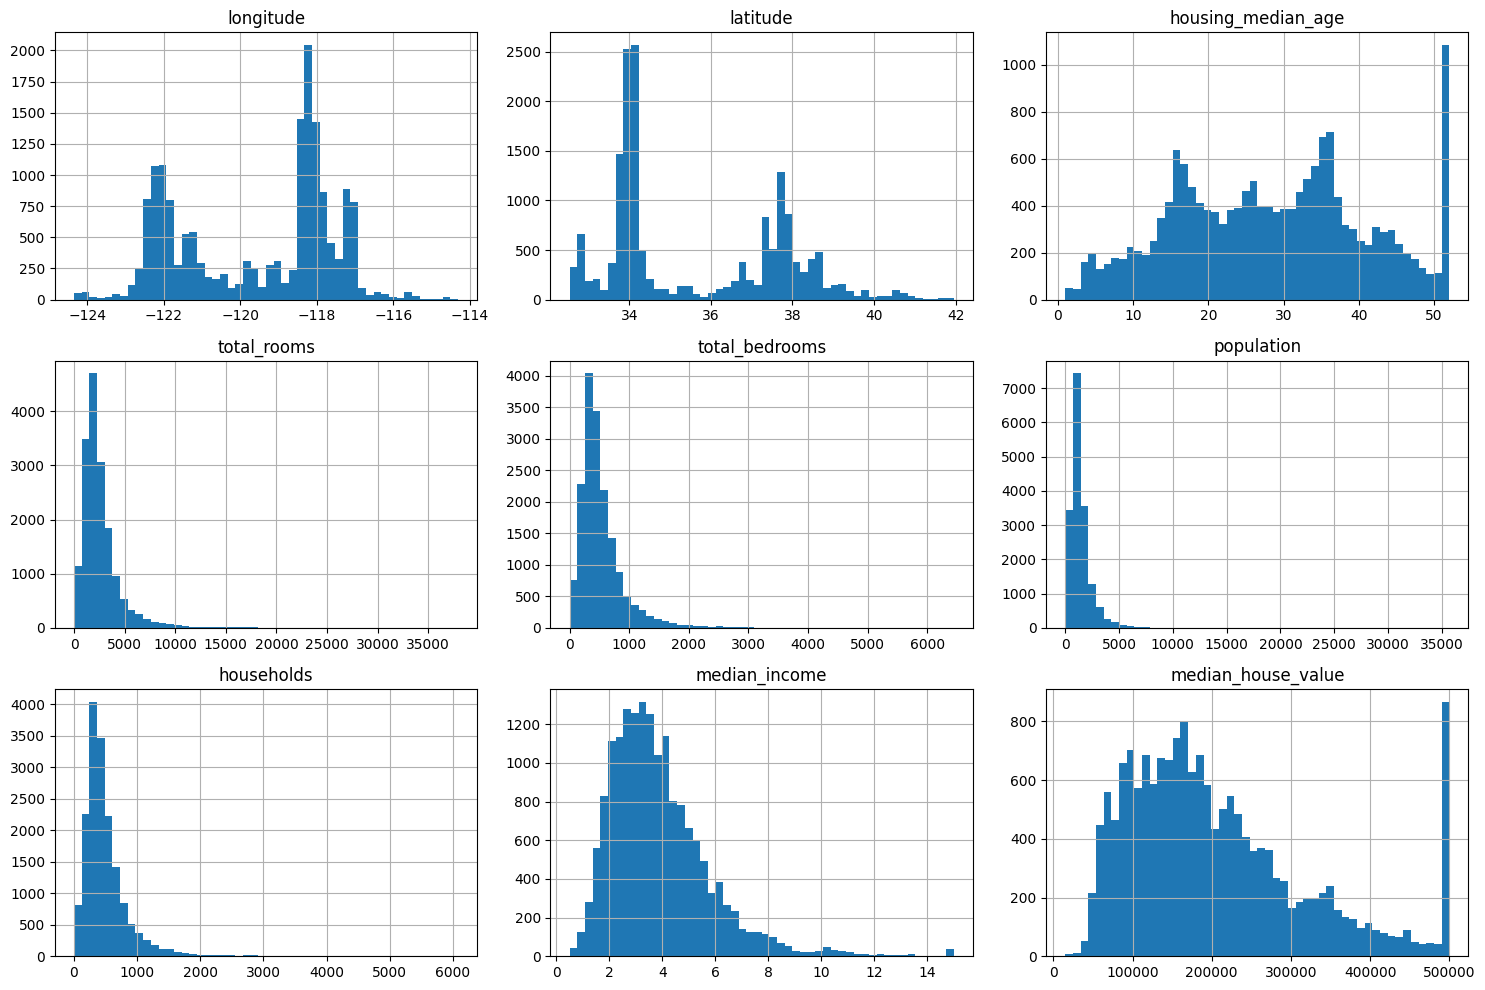

In [7]:
# Histogramas de las variables originales
train.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()

In [8]:
# Ver distribución de las variables numéricas
variables_numericas = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

for var in variables_numericas:
    print(f"\n--- {var} ---")
    print(f"Mínimo: {train[var].min()}")
    print(f"Máximo: {train[var].max()}")
    print(f"Sesgo: {train[var].skew():.2f}")  # Si es > 1 o < -1, está sesgada


--- total_rooms ---
Mínimo: 2.0
Máximo: 37937.0
Sesgo: 4.00

--- total_bedrooms ---
Mínimo: 1.0
Máximo: 6445.0
Sesgo: 3.32

--- population ---
Mínimo: 3.0
Máximo: 35682.0
Sesgo: 5.19

--- households ---
Mínimo: 1.0
Máximo: 6082.0
Sesgo: 3.34

--- median_income ---
Mínimo: 0.4999
Máximo: 15.0001
Sesgo: 1.63


In [9]:
# Crear copia del dataset para transformaciones
train_transformed = train.copy()

# Transformación 1: LOGARÍTMICA (para total_rooms, total_bedrooms, population, households)
import numpy as np

train_transformed['log_total_rooms'] = np.log1p(train_transformed['total_rooms'])
train_transformed['log_total_bedrooms'] = np.log1p(train_transformed['total_bedrooms'])
train_transformed['log_population'] = np.log1p(train_transformed['population'])
train_transformed['log_households'] = np.log1p(train_transformed['households'])

# Transformación 2: RAÍZ CUADRADA (para median_income)
train_transformed['sqrt_median_income'] = np.sqrt(train_transformed['median_income'])

print("✅ Transformaciones aplicadas correctamente")
print("\nNuevas columnas creadas:")
print([col for col in train_transformed.columns if col.startswith(('log_', 'sqrt_'))])

✅ Transformaciones aplicadas correctamente

Nuevas columnas creadas:
['log_total_rooms', 'log_total_bedrooms', 'log_population', 'log_households', 'sqrt_median_income']


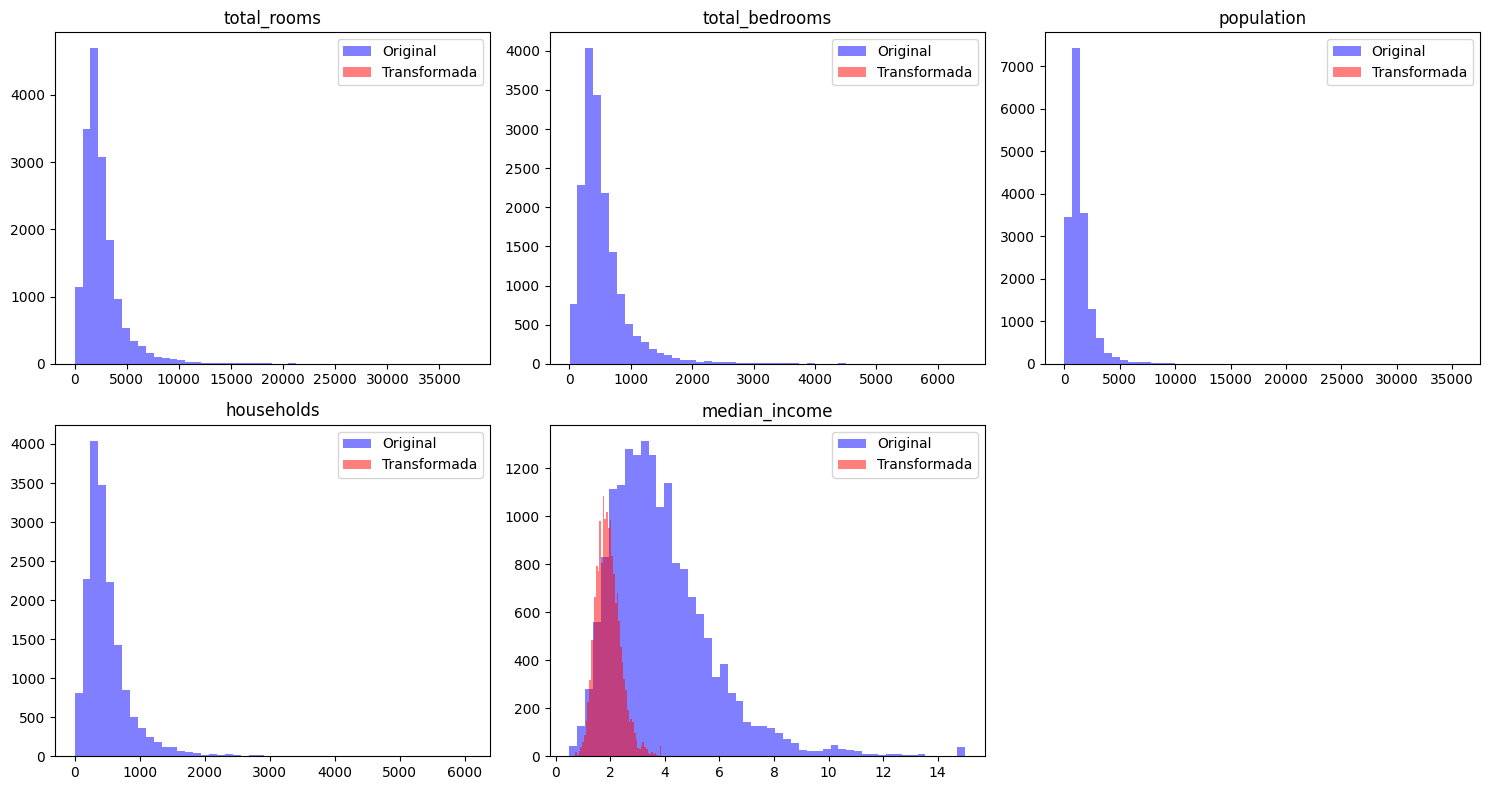

✅ Histogramas comparativos listos


In [10]:
# Comparar distribuciones originales vs transformadas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

variables_a_mostrar = [
    ('total_rooms', 'log_total_rooms'),
    ('total_bedrooms', 'log_total_bedrooms'),
    ('population', 'log_population'),
    ('households', 'log_households'),
    ('median_income', 'sqrt_median_income')
]

for i, (original, transformada) in enumerate(variables_a_mostrar):
    axes[i].hist(train[original], bins=50, alpha=0.5, label='Original', color='blue')
    axes[i].hist(train_transformed[transformada], bins=50, alpha=0.5, label='Transformada', color='red')
    axes[i].set_title(f'{original}')
    axes[i].legend()

axes[5].axis('off')  # Ocultar el último subplot vacío
plt.tight_layout()
plt.show()

print("✅ Histogramas comparativos listos")

MÉTRICAS DE DESEMPEÑO DEL MODELO

1. ERROR CUADRÁTICO MEDIO (MSE):
   Entrenamiento: 6,402,532,558.18
   Prueba: 6,193,000,875.15
   📌 Fórmula: MSE = (1/n) * Σ(y_real - y_pred)²

2. ERROR ABSOLUTO MEDIO (MAE):
   Entrenamiento: $60,069.90
   Prueba: $58,924.78
   📌 Fórmula: MAE = (1/n) * Σ|y_real - y_pred|

3. COEFICIENTE DE DETERMINACIÓN (R²):
   Entrenamiento: 0.5210 (52.10%)
   Prueba: 0.5505 (55.05%)
   📌 Fórmula: R² = 1 - Σ(y_real - y_pred)² / Σ(y_real - y_promedio)²
   📌 Rango: 0 a 1 (1 = perfecto)


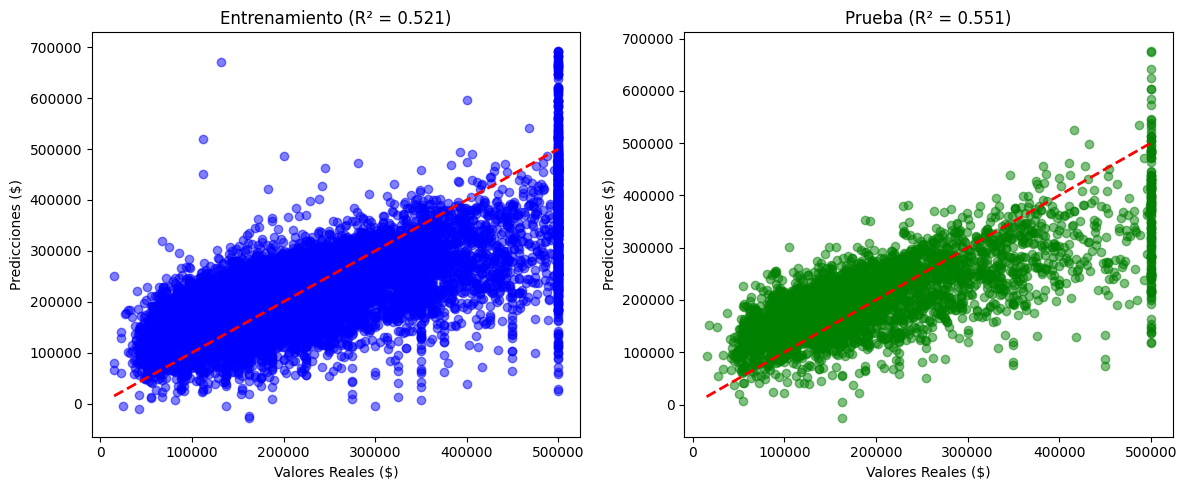


✅ Modelo entrenado y evaluado correctamente


In [11]:
# ============================================
# MODELO DE REGRESIÓN LINEAL Y MÉTRICAS
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Preparar los datos para el modelo
# Usaremos las variables transformadas
X = train_transformed[['median_income', 'sqrt_median_income', 'log_total_rooms',
                       'log_population', 'housing_median_age']]
y = train['median_house_value']  # La variable a predecir

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Hacer predicciones
y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

# Calcular métricas
print("="*50)
print("MÉTRICAS DE DESEMPEÑO DEL MODELO")
print("="*50)

# 1. MSE (Error Cuadrático Medio)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"\n1. ERROR CUADRÁTICO MEDIO (MSE):")
print(f"   Entrenamiento: {mse_train:,.2f}")
print(f"   Prueba: {mse_test:,.2f}")
print(f"   📌 Fórmula: MSE = (1/n) * Σ(y_real - y_pred)²")

# 2. MAE (Error Absoluto Medio)
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f"\n2. ERROR ABSOLUTO MEDIO (MAE):")
print(f"   Entrenamiento: ${mae_train:,.2f}")
print(f"   Prueba: ${mae_test:,.2f}")
print(f"   📌 Fórmula: MAE = (1/n) * Σ|y_real - y_pred|")

# 3. R² (Coeficiente de Determinación)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print(f"\n3. COEFICIENTE DE DETERMINACIÓN (R²):")
print(f"   Entrenamiento: {r2_train:.4f} ({r2_train*100:.2f}%)")
print(f"   Prueba: {r2_test:.4f} ({r2_test*100:.2f}%)")
print(f"   📌 Fórmula: R² = 1 - Σ(y_real - y_pred)² / Σ(y_real - y_promedio)²")
print(f"   📌 Rango: 0 a 1 (1 = perfecto)")

# Gráfico de predicciones vs valores reales
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, c='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Valores Reales ($)')
plt.ylabel('Predicciones ($)')
plt.title(f'Entrenamiento (R² = {r2_train:.3f})')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, c='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reales ($)')
plt.ylabel('Predicciones ($)')
plt.title(f'Prueba (R² = {r2_test:.3f})')

plt.tight_layout()
plt.show()

print("\n✅ Modelo entrenado y evaluado correctamente")